In [1]:
import os
import tqdm
import requests
import typing as tt

import sys
from pathlib import Path
import pandas as pd
import numpy as np

import data
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.dataset as ds
import pyarrow.feather as pf

In [2]:
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

pio.templates.default = 'plotly_white'

# Example routes

In [3]:
R1_LON1 = -74.01738
R1_LAT1 = 40.70483
R1_LON2 = -74.00356
R1_LAT2 = 40.71726

R2_LON1 = -74.0434874
R2_LAT1 = 40.7117475
R2_LON2 = -74.01738
R2_LAT2 = 40.70483

In [4]:
t = pa.table({"lat1": [R1_LAT1, R2_LAT1], "lon1": [R1_LON1, R2_LON1], 
              "lat2": [R1_LAT2, R2_LAT2], "lon2": [R1_LON2, R2_LON2]})

In [5]:
expr = data.compute_distance(ds.field("lat1"), ds.field("lon1"), ds.field("lat2"), ds.field("lon2"))

In [6]:
dataset = ds.dataset(t)
dataset.to_table(columns={"dist": expr})

pyarrow.Table
dist: halffloat
----
dist: [[1.8076171875,2.33203125]]

# Map routes

## Google maps api

In [57]:
# set your key here
GOOGLE_MAPS_KEY = os.environ.get("GOOGLE_MAPS_KEY")
ROUTE_URL = "https://routes.googleapis.com/directions/v2:computeRoutes"

Test request https://developers.google.com/maps/documentation/routes/compute_route_directions#example_http_route_request

In [62]:
req_body = {
  "origin":{
    "location":{
      "latLng":{         
        "latitude": 40.757381439208984,
        "longitude": -73.99649810791016
      }
    }
  },
  "destination":{
    "location":{
      "latLng":{
        "latitude": 40.75743103027344,
        "longitude": -73.9965591430664
      }
    }
  },
  "travelMode": "DRIVE",
  "routingPreference": "TRAFFIC_AWARE",
  "computeAlternativeRoutes": False,
  "routeModifiers": {
    "avoidTolls": False,
    "avoidHighways": False,
    "avoidFerries": False
  },
  "languageCode": "en-US",
  "units": "METRIC"    
}

In [63]:
headers = {
    'X-Goog-Api-Key': GOOGLE_MAPS_KEY,
    'X-Goog-FieldMask': 'routes.duration,routes.distanceMeters,routes.polyline.encodedPolyline',
}

In [64]:
res = requests.post(ROUTE_URL, json=req_body, headers=headers)

In [65]:
res.json()

{'routes': [{'distanceMeters': 8,
   'duration': '0s',
   'polyline': {'encodedPolyline': 'qlwwFdmsbMKJ'}}]}

In [7]:
def query_route(
    src_lat: float, src_lon: float, 
    dst_lat: float, dst_lon: float, key: str,
    need_polyline: bool = False,
) -> tt.Optional[dict]:
    req_body = {
      "origin":{
        "location":{
          "latLng":{"latitude": src_lat, "longitude": src_lon,}
        }
      },
      "destination":{
        "location":{
          "latLng":{"latitude": dst_lat, "longitude": dst_lon,}
        }
      },
      "travelMode": "DRIVE",
      "routingPreference": "TRAFFIC_UNAWARE",
      "computeAlternativeRoutes": False,
      "routeModifiers": {"avoidTolls": False, "avoidHighways": False, "avoidFerries": False},
      "languageCode": "en-US",
      "units": "METRIC"    
    }

    headers = {
        'X-Goog-Api-Key': GOOGLE_MAPS_KEY,
        'X-Goog-FieldMask': 
            'routes.duration,routes.distanceMeters' + 
            (',routes.polyline.encodedPolyline' if need_polyline else ''),
    }
    res = requests.post(
        "https://routes.googleapis.com/directions/v2:computeRoutes", 
        json=req_body, headers=headers
    )
    if res.status_code != 200:
        return None
    data = res.json()
    route = data['routes'][0]
    dist = route['distanceMeters']
    duration = int(route['duration'][:-1])
    result = {
        'distance': dist, 
        'duration': duration,
    }
    if need_polyline:
        poly = route['polyline']['encodedPolyline']
        result['polyline'] = poly
    return result

In [23]:
query_route(40.721317, -73.844315, 40.712276, -73.84161, GOOGLE_MAPS_KEY, need_polyline=True)

{'distance': 1449,
 'duration': 357,
 'polyline': 'mkpwFxuuaMpJeYNg@bg@jXfByGdA_D[]'}

You can check the polyline here: https://developers.google.com/maps/documentation/routes/polylinedecoder

## Using OSMR router

Google Maps API is very expensive for our purpose: 
we need at least 55M routes, with landmarks it becomes 18 times more - 1B route requests.

So we will use free OSM router with NY maps.
Run the router with `run.sh` script from `Chapter4/osmr` directory. 
On the first run it will take some time to complete.

In [7]:
# for local machine
#ROUTER_URL = "http://localhost:5050/route/v1/driving/"
# remote server
ROUTER_URL = "http://192.168.10.8:5050/route/v1/driving/"

In [8]:
def query_route_osmr(
    src_lat: float, src_lon: float, 
    dst_lat: float, dst_lon: float,
) -> tt.Optional[dict]:
    url = ROUTER_URL + f"{src_lon},{src_lat};{dst_lon},{dst_lat}"
    res = requests.get(url)
    if res.status_code != 200:
        return None
    data = res.json()
    route = data['routes'][0]
    result = {
        'geometry': route['geometry'],
        'distance': route['distance'], 
        'duration': route['duration'],
    }
    return result

In [9]:
query_route_osmr(40.721317, -73.844315, 40.712276, -73.84161)

{'geometry': 'qkpwFvuuaMPe@jKxFp@gB`HkB|C@rGhBfBArBy@jAeBv@aBlCmIfAuB`AbA',
 'distance': 1245.4,
 'duration': 186.7}

In [10]:
query_route_osmr(R1_LAT1, R1_LON1, R1_LAT2, R1_LON2)

{'geometry': 'udmwFjowbMTyDgAFe^kJyPeCeIwBsZmEpA}TcCW^{HpImUZX',
 'distance': 2588.7,
 'duration': 350.6}

In [21]:
query_route_osmr(R2_LAT1, R2_LON1, R2_LAT2, R2_LON2)

{'geometry': 'wonwFtr|bMJkBg@fBaf@{FcDgDq`AcIkA}@TmQ`EkZdB}b@|L}yAvAaFxJ{NlFkH~AQbAn@FxAcC~[boAjSh\\fJOrA',
 'distance': 7698.2,
 'duration': 777.3}

In [11]:
import polyline

In [22]:
points1 = polyline.decode("udmwFjowbMTyDgAFe^kJyPeCeIwBsZmEpA}TcCW^{HpImUZX")
points1

[(40.70491, -74.01734),
 (40.7048, -74.01641),
 (40.70516, -74.01645),
 (40.71015, -74.01463),
 (40.713, -74.01396),
 (40.71463, -74.01336),
 (40.71905, -74.01233),
 (40.71864, -74.00882),
 (40.7193, -74.0087),
 (40.71914, -74.00712),
 (40.71745, -74.00353),
 (40.71731, -74.00366)]

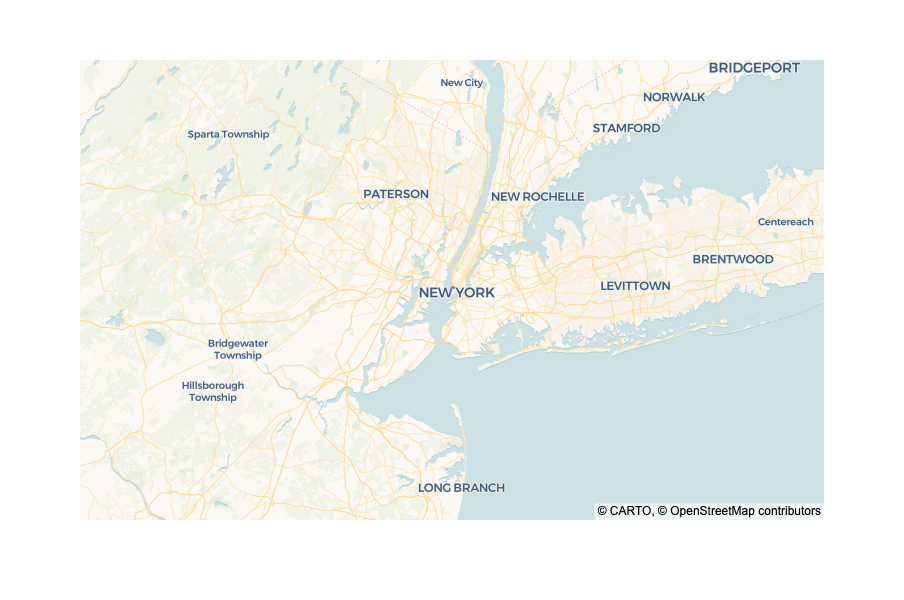

In [23]:
lats, lons = list(zip(*points1))
px.line_map(lat=lats, lon=lons, height=600, width=800)

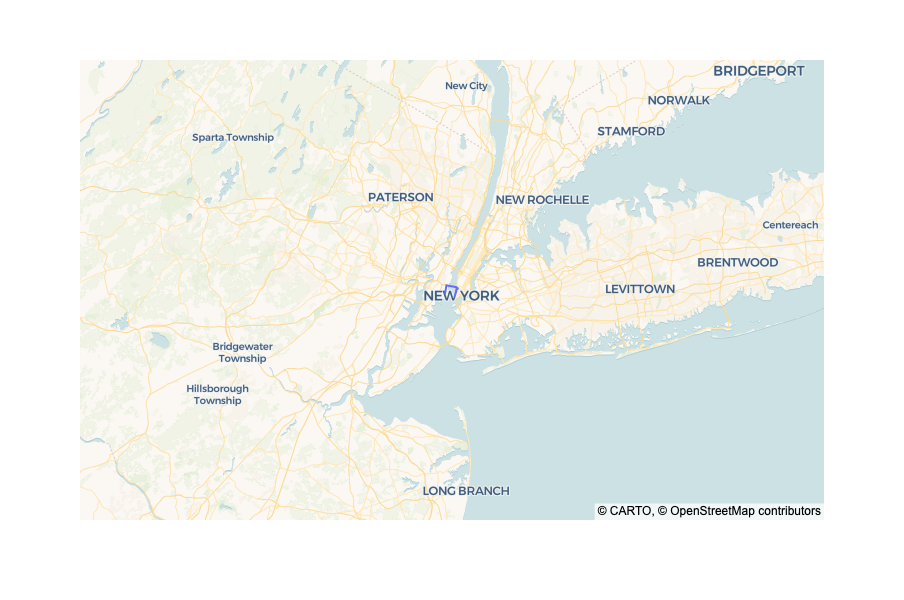

In [24]:
points2 = polyline.decode("wonwFtr|bMJkBg@fBaf@{FcDgDq`AcIkA}@TmQ`EkZdB}b@|L}yA"
                          "vAaFxJ{NlFkH~AQbAn@FxAcC~[boAjSh\\fJOrA")
lats, lons = list(zip(*points2))
px.line_map(lat=lats, lon=lons, height=600, width=800)